In [1]:
import numpy as np 
# 1) create an array
x = np.array([1,2,3])
print(x)

# 2) basic math (vectorized)
y = x*10
print(y)

# 3) matricies
A_zeros = np.zeros((2,2),dtype=np.uint8)
print(A_zeros)

A_ones = np.ones((2,2),dtype = np.uint8)
print(A_ones)

A = np.array([1,2])

# Rotation Matrix
R = np.array([[0,-1],[1,0]])
print(R)

#Dot product 
B = np.dot(R,A)
print(B)

#Inverse of R
R_inverse_aut = np.linalg.inv(R)
print(R_inverse_aut)
R_inverse = np.array([[0,1],[-1,0]])

#Here we got A again 
B_prime = np.dot(R_inverse,B)
print(B_prime)

#shape function 
print(A.shape)


[1 2 3]
[10 20 30]
[[0 0]
 [0 0]]
[[1 1]
 [1 1]]
[[ 0 -1]
 [ 1  0]]
[-2  1]
[[ 0.  1.]
 [-1. -0.]]
[1 2]
(2,)


In [2]:
from PIL import Image 
img = Image.open("../data/lenna.png")
print(f"Size of image (height & width ) : {img.size}")
print(f"Type of image(RGB or Gray scale) : {img.mode}")

#Convert image from RGB to Gray scale image 
gray = img.convert('L')
gray.save("../outputs/lenna_gray_pillow.png")

#Open the image in external tab 
img.show()

Size of image (height & width ) : (512, 512)
Type of image(RGB or Gray scale) : RGB


In [3]:
# Change the size of the image 
img_resized = img.resize((600,600))
img_resized.show()

In [4]:
#Make a rotation for the image 
rotated_img = img.rotate(90)
rotated_img.show()

In [5]:
#Crop section from the image
cropped_img = img.crop((100,100,300,300))
cropped_img.show()

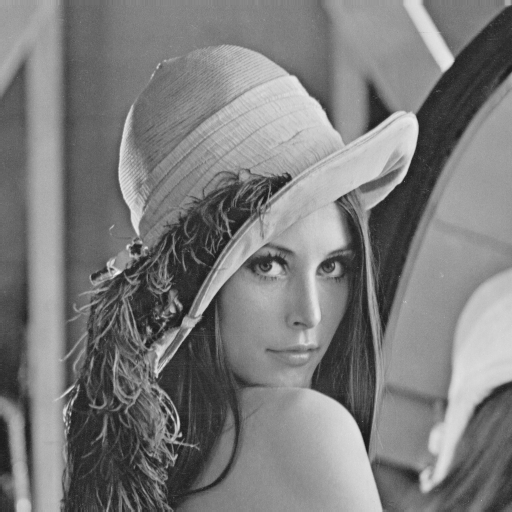

In [6]:
gray

In [7]:
#Getting binary image(just white and black without gray)
threshold = 128 
img_thresolded = gray.point(lambda p :255 if p > threshold else 0 )

**Can you explain what happened?**  


The code converts a grayscale image into a binary image. It checks each pixel value: if the value is greater than 128, it is set to 255 (white); otherwise, it is set to 0 (black). This removes all gray levels and produces an image with only two colors—black and white.



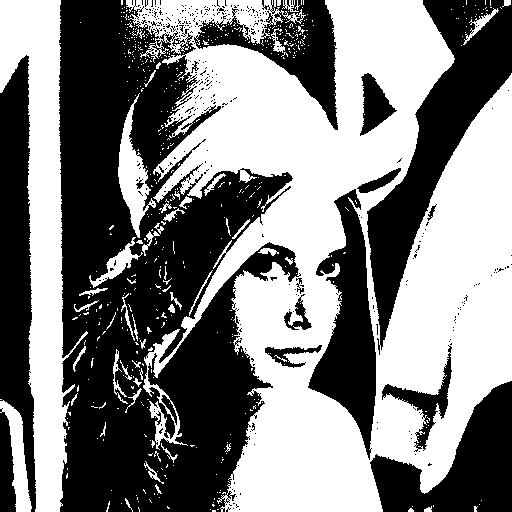

In [8]:
img_thresolded 

**Part A — Warm-up with NumPy (no Pillow/OpenCV yet)**

Task: create an 8×8 checkerboard (0 = black, 255 = white) and print it.

In [9]:
import numpy as np
img0 = np.indices((8,8))
print(img0)
img0 = np.indices((8,8)).sum(axis=0)%2
img0 = (img0*255).astype(np.uint8)
img0

[[[0 0 0 0 0 0 0 0]
  [1 1 1 1 1 1 1 1]
  [2 2 2 2 2 2 2 2]
  [3 3 3 3 3 3 3 3]
  [4 4 4 4 4 4 4 4]
  [5 5 5 5 5 5 5 5]
  [6 6 6 6 6 6 6 6]
  [7 7 7 7 7 7 7 7]]

 [[0 1 2 3 4 5 6 7]
  [0 1 2 3 4 5 6 7]
  [0 1 2 3 4 5 6 7]
  [0 1 2 3 4 5 6 7]
  [0 1 2 3 4 5 6 7]
  [0 1 2 3 4 5 6 7]
  [0 1 2 3 4 5 6 7]
  [0 1 2 3 4 5 6 7]]]


array([[  0, 255,   0, 255,   0, 255,   0, 255],
       [255,   0, 255,   0, 255,   0, 255,   0],
       [  0, 255,   0, 255,   0, 255,   0, 255],
       [255,   0, 255,   0, 255,   0, 255,   0],
       [  0, 255,   0, 255,   0, 255,   0, 255],
       [255,   0, 255,   0, 255,   0, 255,   0],
       [  0, 255,   0, 255,   0, 255,   0, 255],
       [255,   0, 255,   0, 255,   0, 255,   0]], dtype=uint8)

**Describe what you see:**
1. How many unique values exist?
2. What is the pattern?

-The matrix contains two unique values: 0 and 255. The values are arranged in an alternating pattern, forming a checkerboard of black and white squares, where neighboring pixels have opposite values.   

**Your turn (no code shown): create a vertical stripes pattern instead of a checkerboard.**


In [10]:
img0 = np.indices((8,8))[1]%2
img0 = (img0*255).astype(np.uint8)
img0

array([[  0, 255,   0, 255,   0, 255,   0, 255],
       [  0, 255,   0, 255,   0, 255,   0, 255],
       [  0, 255,   0, 255,   0, 255,   0, 255],
       [  0, 255,   0, 255,   0, 255,   0, 255],
       [  0, 255,   0, 255,   0, 255,   0, 255],
       [  0, 255,   0, 255,   0, 255,   0, 255],
       [  0, 255,   0, 255,   0, 255,   0, 255],
       [  0, 255,   0, 255,   0, 255,   0, 255]], dtype=uint8)

**A2) Transformation 1 — scaling (upsampling)**

In [11]:
img = img0.copy()
scaled2 = np.kron(img, np.ones((2, 2), dtype=np.uint8))
print("\nScaled (x2) shape:", scaled2.shape)
print(scaled2)


Scaled (x2) shape: (16, 16)
[[  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255

**Describe what you see:**

What changed in the numbers?
What changed in the size?
- The numbers themselves do not change; each value is repeated in a block (a matrix of ones multiplied by that value).
The size of the matrix increases ,  so the overall dimensions are scaled up.

Your turn: try scaling by 3 instead of 2.

In [12]:
img = img0.copy()
scaled2 = np.kron(img, np.ones((3, 3), dtype=np.uint8))
print("\nScaled (x2) shape:", scaled2.shape)
print(scaled2)


Scaled (x2) shape: (24, 24)
[[  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 

A3) Transformation 2 — rotation by 90 degrees

In [13]:
print(img0)
img = img0.copy()
rot90 = np.rot90(img, k=1) # 90 degrees counter-clockwise
print("\nRotated 90°:")
print(rot90)

[[  0 255   0 255   0 255   0 255]
 [  0 255   0 255   0 255   0 255]
 [  0 255   0 255   0 255   0 255]
 [  0 255   0 255   0 255   0 255]
 [  0 255   0 255   0 255   0 255]
 [  0 255   0 255   0 255   0 255]
 [  0 255   0 255   0 255   0 255]
 [  0 255   0 255   0 255   0 255]]

Rotated 90°:
[[255 255 255 255 255 255 255 255]
 [  0   0   0   0   0   0   0   0]
 [255 255 255 255 255 255 255 255]
 [  0   0   0   0   0   0   0   0]
 [255 255 255 255 255 255 255 255]
 [  0   0   0   0   0   0   0   0]
 [255 255 255 255 255 255 255 255]
 [  0   0   0   0   0   0   0   0]]


**Describe what you see:**
Is the checkerboard different after 90° rotation? Why/why not?
- No, the checkerboard is not different after a 90° rotation because the pattern is symmetric. Although the last column becomes the first row, the overall pattern remains unchanged.

Your turn: rotate by 180° using NumPy.

In [14]:
img = img0.copy()
rot90 = np.rot90(img, k=2) # 90 degrees counter-clockwise
print("\nRotated 90°:")
print(rot90)


Rotated 90°:
[[255   0 255   0 255   0 255   0]
 [255   0 255   0 255   0 255   0]
 [255   0 255   0 255   0 255   0]
 [255   0 255   0 255   0 255   0]
 [255   0 255   0 255   0 255   0]
 [255   0 255   0 255   0 255   0]
 [255   0 255   0 255   0 255   0]
 [255   0 255   0 255   0 255   0]]


**Part B — Tasks with real images**

Task 1 — Read images (Pillow and OpenCV)

1 A) Read with Pillow

In [15]:
from PIL import Image
img_pil = Image.open("../data/lenna.png")
print("Pillow:")
print(" size (W,H):", img_pil.size)
print(" mode:", img_pil.mode)
# Optional display (opens default viewer)
img_pil.show()

Pillow:
 size (W,H): (512, 512)
 mode: RGB


**1B) Read with OpenCV**

In [16]:
import cv2
img_cv = cv2.imread("../data/lenna.png") # BGR
print("OpenCV:")
print(" shape (H,W,C):", img_cv.shape)
print(" dtype:", img_cv.dtype)
# cv2.imshow("Lenna (OpenCV)", img_cv)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

OpenCV:
 shape (H,W,C): (512, 512, 3)
 dtype: uint8


Describe what you see:
Why does Pillow report size as (W,H) but OpenCV shape is (H,W,C)?
- Pillow treats image as graphic object so it gives the height and weight , but Opencv trates it as numpy array so it gives weight , height , channels .

**Your turn: load baboon.png with both libraries and print its size/shape.**

In [17]:
from PIL import Image
img_pil1 = Image.open("../data/baboon.png")
print("Pillow:")
print(" size (W,H):", img_pil1.size)
print(" mode:", img_pil1.mode)
# Optional display (opens default viewer)
img_pil1.show()

Pillow:
 size (W,H): (512, 512)
 mode: RGB


In [18]:
import cv2
img_cv1= cv2.imread("../data/baboon.png") # BGR
print("OpenCV:")
print(" shape (H,W,C):", img_cv1.shape)
print(" dtype:", img_cv1.dtype)
# cv2.imshow("Baboon (OpenCV)", img_cv1)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

OpenCV:
 shape (H,W,C): (512, 512, 3)
 dtype: uint8


**Task 2 — Display images (and save outputs)**

In [19]:
import os
os.makedirs("./outputs", exist_ok=True)
# Save a copy to confirm your pipeline works
img_pil.save("../outputs/lenna_copy_pillow.png")
# Display (may open a viewer window)
img_pil.show(title="Lenna (Pillow)")

In [20]:
cv2.imwrite("../outputs/lenna_copy_opencv.png", img_cv)
# Display (requires a GUI)
# cv2.imshow("Lenna (OpenCV)", img_cv)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

True

Describe what you see:

**Are the saved images identical?**
Yes, they are identical because both libraries save the image data correctly.

**Do the colors look correct in OpenCV?**
No, the colors may look wrong because OpenCV uses BGR instead of RGB, so colors (like red and blue) are swapped.

Your turn: save barbara.png to outputs with both libraries.

In [21]:
img_pil1.save("../outputs/barabara_copy_pillow.png")

img_pil1.show(title="barbara (Pillow)")

In [22]:
cv2.imwrite("../outputs/barbara_copy_opencv.png", img_cv)
# Display (requires a GUI)
# cv2.imshow("barbara (OpenCV)", img_cv)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

True

**Task 3 — Convert color (RGB/BGR and grayscale)**

In [ ]:
gray_pil = img_pil.convert("L")
print("Pillow grayscale mode:", gray_pil.mode)
gray_pil.save("../outputs/lenna_gray_pillow.png")

Pillow grayscale mode: L


In [ ]:
gray_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
print("OpenCV grayscale shape:", gray_cv.shape)
cv2.imwrite("../outputs/lenna_gray_opencv.png", gray_cv)

OpenCV grayscale shape: (512, 512)


True

In [ ]:
rgb_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
cv2.imwrite("../outputs/lenna_rgb_converted_from_opencv.png", rgb_cv)

True

Describe what you see:
What is the difference between a color image array and a grayscale array?

**Your turn: convert baboon.png to grayscale with both libraries.**

In [26]:
gray_pil1 = img_pil1.convert("L")
print("Pillow grayscale mode:", gray_pil1.mode)
gray_pil1.save("../outputs/lenna_gray_pillow.png")

Pillow grayscale mode: L


In [27]:
gray_cv1 = cv2.cvtColor(img_cv1, cv2.COLOR_BGR2GRAY)
print("OpenCV grayscale shape:", gray_cv1.shape)
cv2.imwrite("../outputs/lenna_gray_opencv.png", gray_cv1)

OpenCV grayscale shape: (512, 512)


True

**Task 4 — Inspect pixel values**

In [28]:
# getpixel uses (x, y)
px00 = img_pil.getpixel((0, 0))
px10 = img_pil.getpixel((1, 0))
print("Pillow pixel (0,0):", px00)
print("Pillow pixel (1,0):", px10)

Pillow pixel (0,0): (226, 137, 125)
Pillow pixel (1,0): (226, 137, 125)


In [29]:
# OpenCV array indexing is [y, x] and color is BGR
px00_cv = img_cv[0, 0]
px10_cv = img_cv[0, 1]
print("OpenCV pixel [0,0] (BGR):", px00_cv)
print("OpenCV pixel [0,1] (BGR):", px10_cv)

OpenCV pixel [0,0] (BGR): [125 137 226]
OpenCV pixel [0,1] (BGR): [125 137 226]


In [30]:
import numpy as np
arr_pil = np.array(img_pil) # RGB
print("NumPy from Pillow shape:", arr_pil.shape)
print("arr_pil[0,0] (RGB):", arr_pil[0, 0])

NumPy from Pillow shape: (512, 512, 3)
arr_pil[0,0] (RGB): [226 137 125]


**Describe what you see:**

Explain why img_pil.getpixel((x,y)) vs img_cv[y,x] looks “swapped”.

Explain why the color channel order differs.

- img_pil.getpixel((x, y)) uses (x, y) → (column, row),
while img_cv[y, x] uses [y, x] → (row, column), so they look swapped.
Pillow uses RGB, while OpenCV uses BGR, so the color channels are reversed (red and blue are swapped).

**Your turn: pick a pixel near the center and compare its values in Pillow vs OpenCV.**

In [31]:
h, w = img_cv.shape[:2]
y, x = h // 2, w // 2

px_pil = img_pil.getpixel((x, y))
px_cv = img_cv[y, x]

print("Pillow (RGB):", px_pil)
print("OpenCV (BGR):", px_cv)

Pillow (RGB): (180, 65, 72)
OpenCV (BGR): [ 72  65 180]


**Task 5 — Apply simple transformations**

In [45]:
# Resize (scale down)
small_pil = img_pil.resize((img_pil.size[0] // 2, img_pil.size[1] // 2))
small_pil.save("../outputs/lenna_small_pillow.png")
# Rotate (degrees, around image center)
rot_pil = img_pil.rotate(30) # default expands=False
rot_pil.save("../outputs/lenna_rot30_pillow.png")
# Flip left-right
flip_pil = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
flip_pil.save("../outputs/lenna_flip_lr_pillow.png")

In [44]:
h, w = img_cv.shape[:2]
# Resize
small_cv = cv2.resize(img_cv, (w // 2, h // 2))
cv2.imwrite("../outputs/lenna_small_opencv.png", small_cv)
# Rotate 90 degrees (built-in)
rot90_cv = cv2.rotate(img_cv, cv2.ROTATE_90_COUNTERCLOCKWISE)
cv2.imwrite("../outputs/lenna_rot90_opencv.png", rot90_cv)
# Flip: 1=horizontal, 0=vertical, -1=both
flip_cv = cv2.flip(img_cv, 1)
cv2.imwrite("../outputs/lenna_flip_lr_opencv.png", flip_cv)

True

**Describe what you see:**
**Which library was easier for rotation?**

-Pillow is easier for rotation.
OpenCV requires a transformation matrix (getRotationMatrix2D) and warpAffine for arbitrary angles.

**Your turn: try a different rotation angle in OpenCV (hint: cv2.getRotationMatrix2D + cv2.warpAffine).**

**Search it quickly in the official OpenCV tutorials.**

In [34]:
import cv2

h, w = img_cv.shape[:2]
center = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(center, 30, 1.0)
rot_cv = cv2.warpAffine(img_cv, M, (w, h))

cv2.imwrite("../outputs/lenna_rot30_opencv.png", rot_cv)

True

**Task 6 — Draw geometric shapes**

In [43]:
from PIL import ImageDraw, Image
img = Image.open("../data/lenna.png")
img_draw_pil = img.copy()
draw = ImageDraw.Draw(img_draw_pil)
# Rectangle: [(x0,y0), (x1,y1)]
draw.rectangle([(50, 50), (200, 200)], outline="red", width=3)
# Line: [(x0,y0), (x1,y1)]
draw.line([(0, 0), (img_draw_pil.size[0]-1, img_draw_pil.size[1]-1)], fill="yellow",
width=3)
# Text
draw.text((60, 210), "Lab 1", fill="white")
img_draw_pil.save("../outputs/lenna_draw_pillow.png")
img_draw_pil.show()

In [42]:
img_draw_cv = img_cv.copy()
# Rectangle: top-left, bottom-right
cv2.rectangle(img_draw_cv, (50, 50), (200, 200), (0, 0, 255), 3) # red in BGR
# Line
h, w = img_draw_cv.shape[:2]
cv2.line(img_draw_cv, (0, 0), (w-1, h-1), (0, 255, 255), 3) # yellow in BGR
# Text
cv2.putText(img_draw_cv, "Lab 1", (60, 230), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255,
255, 255), 2)
cv2.imwrite("../outputs/lenna_draw_opencv.png", img_draw_cv)

True

**Describe what you see:**

**Why do we write colors as (B, G, R) tuples in OpenCV but use names like "red" in Pillow?**

Pillow uses color names like "red" or "blue", which makes it easier and more intuitive for humans to understand and use when drawing on images. In contrast, OpenCV represents colors as numerical tuples in the format (B, G, R), because it works directly with image data as arrays.

**Your turn: draw a circle around the center of the image using both libraries.**

In [41]:
from PIL import ImageDraw

img_circle_pil = img.copy()
draw = ImageDraw.Draw(img_circle_pil)

w, h = img_circle_pil.size
center = (w // 2, h // 2)
r = 50

draw.ellipse(
    [(center[0]-r, center[1]-r), (center[0]+r, center[1]+r)],
    outline="blue",
    width=3
)

img_circle_pil.save("../outputs/lenna_circle_pillow.png")

In [40]:
img_circle_cv = img_cv.copy()

h, w = img_circle_cv.shape[:2]
center = (w // 2, h // 2)

cv2.circle(img_circle_cv, center, 50, (255, 0, 0), 3)  # blue in BGR

cv2.imwrite("../outputs/lenna_circle_opencv.png", img_circle_cv)

True